<a href="https://colab.research.google.com/github/malachyor/PyTorch-Tutorial/blob/main/simple_NN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [60]:
# create a model class that inherits nn.module
class Model(nn.Module):

  # input layer has four features of flower
  # there is two hidden layers
  # output is a one of three types of flowers

  def __init__(self, in_features=4, h1=8, h2=9, out_features=3):
    super().__init__()
    self.fc1 = nn.Linear(in_features, h1)
    self.fc2 = nn.Linear(h1,h2)
    self.out = nn.Linear(h2,out_features)


  def move_forward(self,x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.out(x)

    return x


# seed
torch.manual_seed(41)

# create an object
model = Model()

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [62]:
url = 'https://gist.githubusercontent.com/netj/8836201/raw/6f9306ad21398ea43cba4f7d537619d0e07d5ae3/iris.csv'
my_df = pd.read_csv(url)

In [63]:
# change flower names to numbers
my_df['variety'] = my_df['variety'].replace('Setosa', 0.0)
my_df['variety'] = my_df['variety'].replace('Versicolor', 1.0)
my_df['variety'] = my_df['variety'].replace('Virginica', 2.0)


/tmp/ipykernel_5627/1461136981.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_df['variety'] = my_df['variety'].replace('Virginica', 2.0)


In [64]:
# training
X = my_df.drop('variety', axis=1)
y = my_df['variety']

# convert to tensors
X = X.values
y = y.values

In [65]:
# training
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

In [66]:
# convert to tensors
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [67]:
# Set criterion of model to measure the error
criterion = nn.CrossEntropyLoss()
# choose an optimiser and set learning rate lr
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)


In [68]:
# train model
epochs = 100
losses = []

for i in range(epochs):

  # go forward
  y_pred = model.move_forward(X_train)

  # measure loss
  loss = criterion(y_pred, y_train)
  losses.append(loss.detach().numpy())

  # print loss
  #if i % 10 == 0:
    #print(f'Epoch: {i} and loss {loss}')

  # back propagation
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

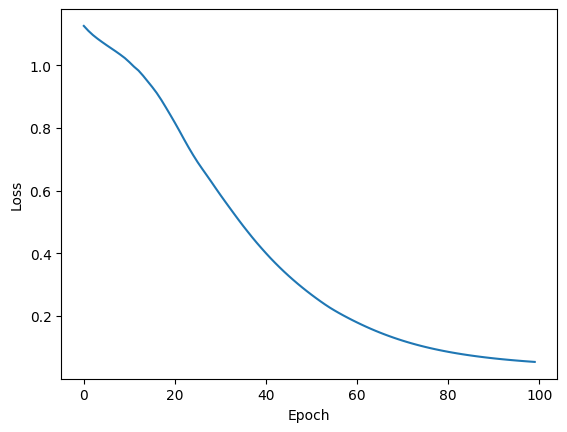

In [69]:
# graph
plt.plot(range(epochs), losses)
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.show()